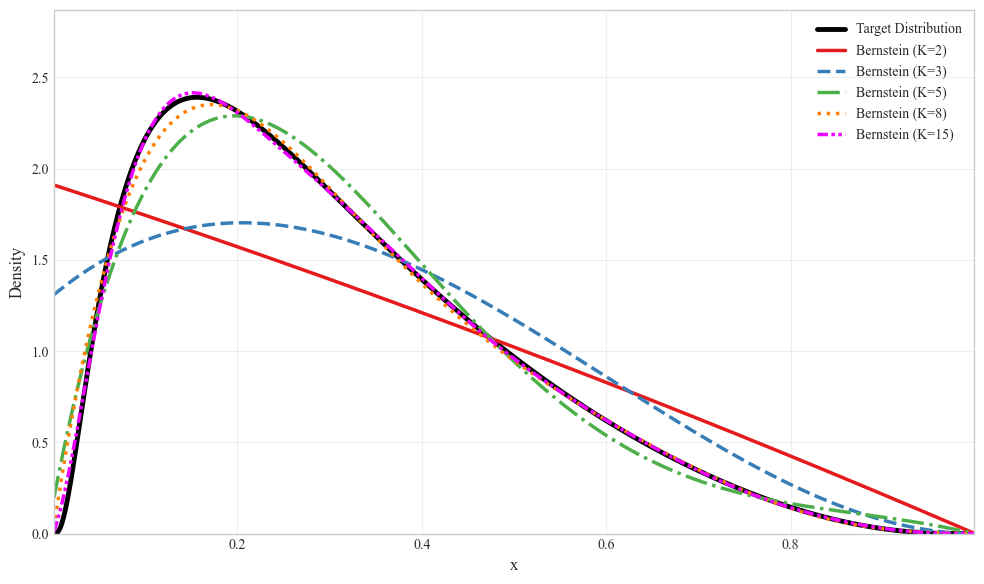

<Figure size 1000x600 with 0 Axes>

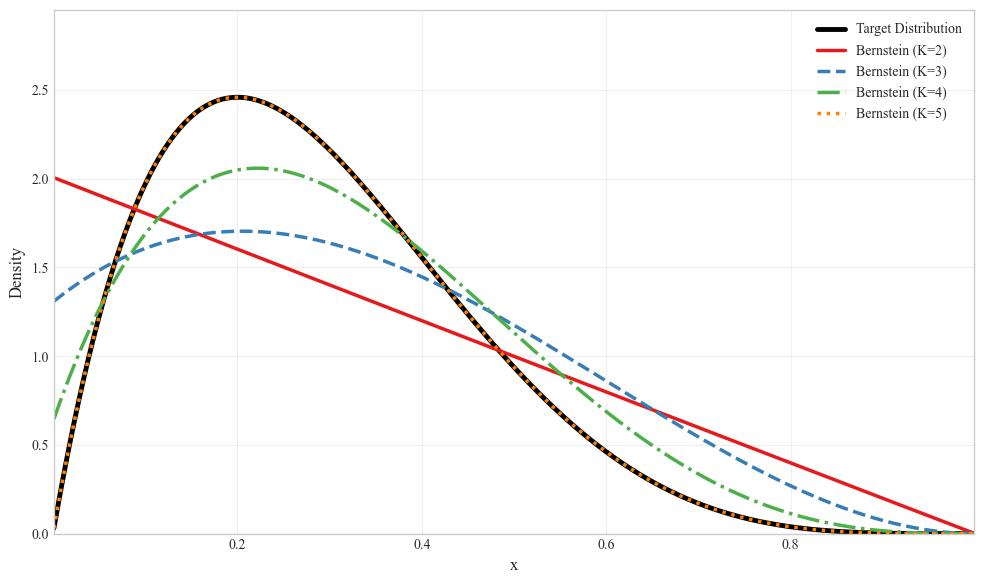

<Figure size 1000x600 with 0 Axes>

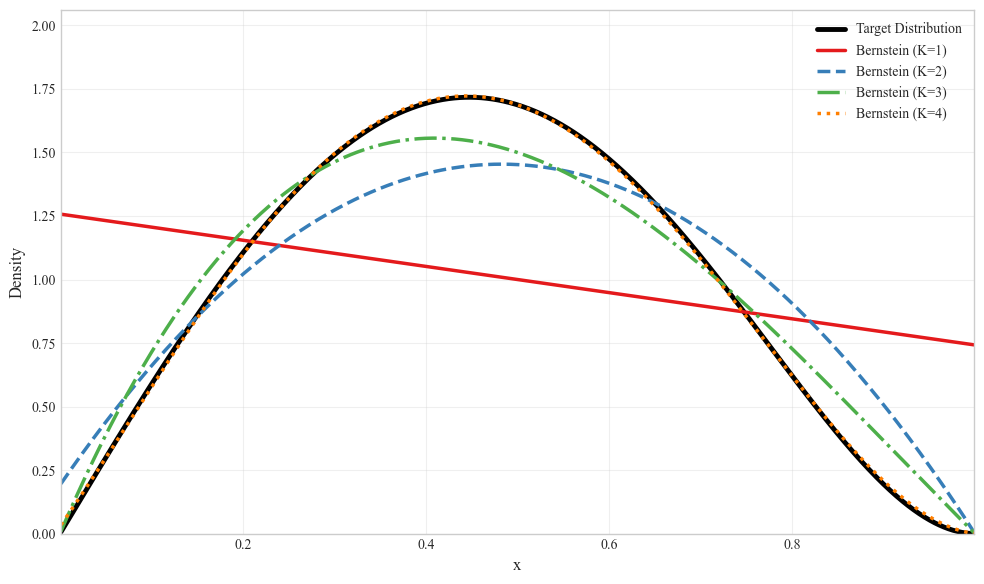

<Figure size 1000x600 with 0 Axes>

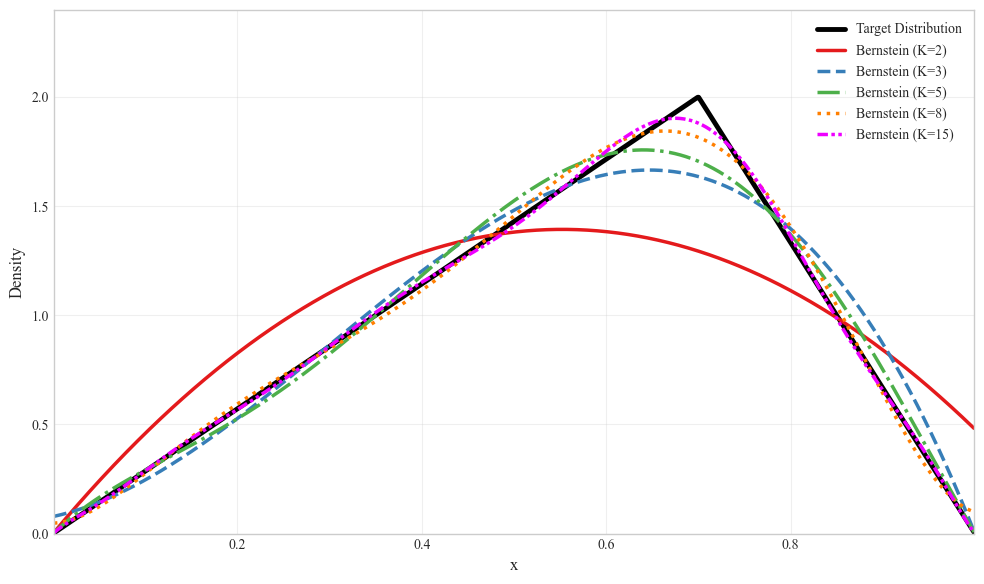

<Figure size 1000x600 with 0 Axes>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, beta
from scipy.special import logit, expit
from scipy.optimize import nnls
import matplotlib as mpl

# 设置学术论文风格的绘图参数
def set_academic_style():
    """设置学术论文风格的绘图参数"""
    plt.style.use('seaborn-v0_8-whitegrid')
    mpl.rcParams['figure.figsize'] = [10, 6]
    mpl.rcParams['figure.dpi'] = 100
    mpl.rcParams['savefig.dpi'] = 300
    mpl.rcParams['font.size'] = 12
    mpl.rcParams['legend.fontsize'] = 10
    mpl.rcParams['axes.titlesize'] = 14
    mpl.rcParams['axes.labelsize'] = 12
    mpl.rcParams['xtick.labelsize'] = 10
    mpl.rcParams['ytick.labelsize'] = 10
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
    mpl.rcParams['mathtext.fontset'] = 'stix'

# 定义各种分布函数
def logit_normal_pdf(x, mu=0, sigma=1):
    """Logit-Normal 分布的密度函数"""
    with np.errstate(divide='ignore', invalid='ignore'):
        mask = (x > 0) & (x < 1)
        result = np.zeros_like(x)
        result[mask] = norm.pdf(logit(x[mask]), mu, sigma) / (x[mask] * (1 - x[mask]))
        return result

def beta_pdf(x, a=2, b=5):
    """Beta 分布的密度函数"""
    return beta.pdf(x, a, b)

def kumaraswamy_pdf(x, a=2, b=3):
    """Kumaraswamy 分布的密度函数"""
    return a * b * (x ** (a - 1)) * ((1 - x ** a) ** (b - 1))

def uniform_pdf(x):
    """均匀分布的密度函数"""
    return np.ones_like(x)

def triangular_pdf(x, mode=0.5):
    """三角分布的密度函数"""
    result = np.zeros_like(x)
    mask1 = (x >= 0) & (x <= mode)
    mask2 = (x > mode) & (x <= 1)
    
    if mode > 0:
        result[mask1] = 2 * x[mask1] / mode
    else:
        result[mask1] = 0
        
    if mode < 1:
        result[mask2] = 2 * (1 - x[mask2]) / (1 - mode)
    else:
        result[mask2] = 0
        
    return result

# 定义 Bernstein 多项式相关函数
def bernstein_pdf(x, lambda_weights):
    """Bernstein 多项式密度函数"""
    K = len(lambda_weights) - 1
    result = np.zeros_like(x)
    for k in range(K + 1):
        result += lambda_weights[k] * beta.pdf(x, k + 1, K - k + 1)
    return result

def compute_bernstein_weights(target_pdf, K, n_samples=1000):
    """通过最小二乘拟合计算 Bernstein 多项式的权重"""
    x_samples = np.linspace(0.001, 0.999, n_samples)
    target_values = target_pdf(x_samples)
    
    # 构建设计矩阵
    design_matrix = np.zeros((len(x_samples), K + 1))
    for k in range(K + 1):
        design_matrix[:, k] = beta.pdf(x_samples, k + 1, K - k + 1)
    
    # 使用非负最小二乘法拟合权重
    weights, _ = nnls(design_matrix, target_values)
    
    # 归一化权重
    if weights.sum() > 0:
        weights /= weights.sum()
    
    return weights

# 绘图函数 - 使用增强的颜色和线型区分度
def plot_bernstein_approximation(target_pdf, dist_name, K_values=None, x_range=(0.001, 0.999)):
    """
    绘制 Bernstein 多项式对目标分布的逼近
    
    参数:
    target_pdf: 目标分布的概率密度函数
    dist_name: 分布名称 (用于标题)
    K_values: Bernstein 多项式的 K 值列表
    x_range: x 轴的范围
    """
    if K_values is None:
        K_values = [2, 3, 5, 10, 20]
    
    # 设置学术风格
    set_academic_style()
    
    # 创建图形
    plt.figure(figsize=(10, 6))
    
    # 生成 x 值
    x = np.linspace(x_range[0], x_range[1], 1000)
    
    # 绘制目标分布
    target_density = target_pdf(x)
    plt.plot(x, target_density, 'k-', linewidth=3.5, label='Target Distribution')
    
    # 使用更鲜明的颜色方案和不同的线型
    colors = ['#E41A1C', '#377EB8', '#4DAF4A', '#FF7F00', "#EE00FF"]  # 鲜明的颜色
    line_styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1, 1, 1))]  # 不同的线型
    
    # 绘制不同 K 值的 Bernstein 多项式逼近
    for i, K in enumerate(K_values):
        weights = compute_bernstein_weights(target_pdf, K)
        bernstein_density = bernstein_pdf(x, weights)
        
        # 循环使用颜色和线型
        color_idx = i % len(colors)
        style_idx = i % len(line_styles)
        
        plt.plot(x, bernstein_density, 
                 color=colors[color_idx], 
                 linestyle=line_styles[style_idx],
                 linewidth=2.5, 
                 label=f'Bernstein (K={K})')
    
    # 设置图表标题和标签
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.xlim(x_range)
    plt.ylim(0, max(target_density) * 1.2)
    plt.grid(True, alpha=0.3)
    plt.legend(loc = 'best')

    # 显示图形
    plt.tight_layout()
    plt.show()
    
    # 返回图形对象，以便进一步操作或保存
    return plt.gcf()

# 使用示例
if __name__ == "__main__":
    # 示例1: 绘制 Logit-Normal 分布的逼近
    logit_normal = lambda x: logit_normal_pdf(x, mu=-1, sigma=1)
    fig1 = plot_bernstein_approximation(logit_normal, "Logit-Normal(0, 1.5)", K_values=[2, 3, 5, 8, 15])
    
    # 示例2: 绘制 Beta 分布的逼近
    beta_dist = lambda x: beta_pdf(x, a=2, b=5)
    fig2 = plot_bernstein_approximation(beta_dist, "Beta(2, 5)", K_values=[2, 3, 4, 5])
    
    # 示例3: 绘制 Kumaraswamy 分布的逼近
    kumaraswamy_dist = lambda x: kumaraswamy_pdf(x, a=2, b=3)
    fig3 = plot_bernstein_approximation(kumaraswamy_dist, "Kumaraswamy(2, 3)", K_values=[1, 2, 3, 4])
    
    # 示例5: 绘制三角分布的逼近
    triangular_dist = lambda x: triangular_pdf(x, mode=0.7)
    fig4 = plot_bernstein_approximation(triangular_dist, "Triangular(mode=0.7)", K_values=[2, 3, 5, 8, 15])
    
    # 保存图形 (取消注释以使用)
    # fig1.savefig('logit_normal_approximation.png', bbox_inches='tight', dpi=300)
    # fig2.savefig('beta_approximation.png', bbox_inches='tight', dpi=300)
    # fig3.savefig('kumaraswamy_approximation.png', bbox_inches='tight', dpi=300)
    # fig4.savefig('triangular_approximation.png', bbox_inches='tight', dpi=300)